### Imports

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset


### Load kedro

In [2]:
os.chdir("../../")

%load_ext kedro.ipython

[07/30/26 12:20:20] INFO     Using                                                                  ]8;id=993115;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=530110;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

[07/30/26 12:20:21] INFO     Registered line magic '%reload_kedro'                                   ]8;id=890932;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=670437;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=506228;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=334072;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=798788;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10599;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[07/30/26 12:20:25] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=267942;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=554392;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

                    WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=713049;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=854364;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[07/30/26 12:21:06] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=264206;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=505584;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[07/30/26 12:21:07] INFO     Kedro project cxr-training-pipeline                                    ]8;id=635948;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=711669;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=877467;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=73090;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=70867;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=556730;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

In [3]:
from src.cxr_training_pipeline.utils.segmentation_utils import (
    get_combined_mask_by_image_index,
    get_bbox_coordinates,
    crop_resize_with_mask,
    crop_to_bbox
)

### Files

In [4]:
xray_train_val = catalog.load("xray_train_val")
xray_test = catalog.load("xray_test")
segmentation_masks = catalog.load("cxr8_segmentation_masks")

                    INFO     Loading data from xray_train_val (CSVDataset)...                  ]8;id=101419;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=908008;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from xray_test (CSVDataset)...                       ]8;id=480214;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=566301;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from cxr8_segmentation_masks (CSVDataset)...         ]8;id=512722;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=502942;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [5]:
segmentation_masks.head()

,Image Index,Dice RCA (Mean),Dice RCA (Max),Landmarks,Left Lung,Right Lung,Heart,Height,Width
0,00025787_047.png,0.826465,0.870102,"488,115,449,118,411,132,374,153,344,177,324,20...",200402 3 201422 11 202442 18 203463 24 204483 ...,118243 8 119254 24 120265 40 121281 51 122302 ...,448036 9 449048 27 450064 41 451086 48 452107 ...,1024,1024
1,00026251_000.png,0.833988,0.928886,"426,124,386,128,345,146,303,171,270,203,246,23...",136822 22 137826 46 138848 52 139870 58 140892...,127399 7 128413 21 129427 35 130441 49 131458 ...,445964 26 446985 33 448007 40 449028 47 450049...,1024,1024
2,00026194_002.png,0.759308,0.794598,"439,217,402,226,371,245,345,271,324,297,311,32...",189085 9 190096 27 191113 39 192135 45 193158 ...,221645 20 222646 45 223666 50 224686 56 225706...,395796 5 396816 13 397836 21 398856 29 399877 ...,1024,1024
3,00025227_012.png,0.903819,0.930990,"397,79,357,82,314,98,274,128,236,165,212,205,1...",100976 22 101998 45 103020 49 104042 53 105064...,81288 8 82299 23 83309 40 84325 50 85346 55 86...,498141 13 499161 29 500181 36 501201 43 502221...,1024,1024
4,00028166_003.png,0.850303,0.869093,"392,180,374,184,353,201,327,225,304,250,284,27...",163435 4 164455 12 165475 20 166496 27 167516 ...,184711 4 185731 12 186750 20 187770 27 188791 ...,464455 11 465455 37 466458 59 467469 74 468485...,1024,1024


### Cropping image to bbox

In [6]:
def precompute_mask_cropped_images_to_npy(
    df: pd.DataFrame,
    segmentation_masks_df: pd.DataFrame,
    images_dir: str,
    output_path: str,
    image_col: str = "image_index",
    output_size: int = 512,
    margin_ratio: float = 0.08,
    min_bbox_size: int = 64,
) -> None:
    images_dir = Path(images_dir)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    n = len(df)
    arr = np.lib.format.open_memmap(
        output_path,
        dtype=np.uint8,
        mode="w+",
        shape=(n, output_size, output_size),
    )

    for i, image_name in enumerate(tqdm(df[image_col].tolist(), total=n)):
        img_path = images_dir / image_name

        with Image.open(img_path) as img:
            img_np = np.array(img.convert("L"), dtype=np.uint8)

        img_np = crop_resize_with_mask(
            img_np=img_np,
            image_index=image_name,
            segmentation_masks_df=segmentation_masks_df,
            output_size=output_size,
            margin_ratio=margin_ratio,
            min_bbox_size=min_bbox_size,
        )

        arr[i] = img_np

    arr.flush()
    print(f"Saved memmap to: {output_path}")

In [7]:
def get_image(idx: int) -> np.ndarray:
    image_index = segmentation_masks.loc[idx, "Image Index"]
    img_path = os.path.join("data", "01_raw", "images", image_index)
    return np.array(plt.imread(img_path))

Image: 00025573_001.png
Bounding Box Coordinates: (156, 23, 813, 675)


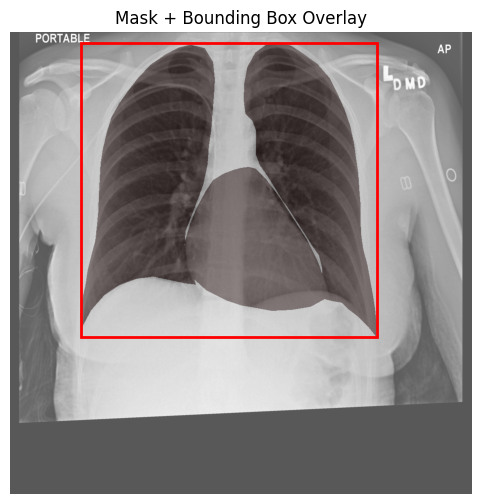

In [8]:
idx = 1251
image = get_image(idx)
image_index = segmentation_masks.loc[idx, "Image Index"]

combined_mask = get_combined_mask_by_image_index(
    image_index=image_index,
    segmentation_masks_df=segmentation_masks,
    height=1024,
    width=1024,
 )
bbox_coords = get_bbox_coordinates(combined_mask)
print(f"Image: {image_index}")
print(f"Bounding Box Coordinates: {bbox_coords}")

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.imshow(combined_mask, cmap="pink_r", alpha=0.35)
if bbox_coords is not None:
    x_min, y_min, x_max, y_max = bbox_coords
    rect = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        edgecolor="red",
        facecolor="none",
        linewidth=2,
    )
    plt.gca().add_patch(rect)
plt.title("Mask + Bounding Box Overlay")
plt.axis("off")
plt.show()

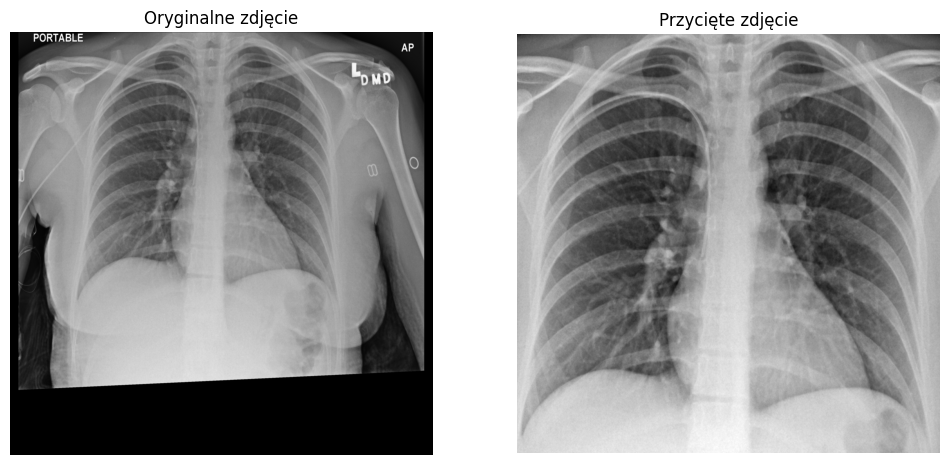

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Oryginalne zdjęcie")
axes[0].axis("off")
cropped_image = crop_to_bbox(image, bbox_coords)
axes[1].imshow(cropped_image, cmap="gray")
axes[1].set_title("Przycięte zdjęcie")
axes[1].axis("off")
plt.show()

### Precompute cropped train/test arrays

In [10]:
OUT_DIR = Path("data/02_intermediate/precomputed_images_masked")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [11]:
# precompute_mask_cropped_images_to_npy(
#     df=xray_train_val,
#     segmentation_masks_df=segmentation_masks,
#     images_dir="data/01_raw/images",
#     output_path=OUT_DIR / "train_images.npy",
#     image_col="image_index",
#     output_size=224,
#     margin_ratio=0.08,
#     min_bbox_size=64,
#  )

# precompute_mask_cropped_images_to_npy(
#     df=xray_test,
#     segmentation_masks_df=segmentation_masks,
#     images_dir="data/01_raw/images",
#     output_path=OUT_DIR / "test_images.npy",
#     image_col="image_index",
#     output_size=224,
#     margin_ratio=0.08,
#     min_bbox_size=64,
#  )

### Load precomputed arrays and build dataset

In [12]:
from cxr_training_pipeline.datasets.cxr_dataset import ImageOnlyDataset

PATHOLOGY_LIST = [
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia",
    "Hernia",
]

train_images_masked = np.load(OUT_DIR / "train_images.npy", mmap_mode="r")
test_images_masked = np.load(OUT_DIR / "test_images.npy", mmap_mode="r")

train_labels = xray_train_val[PATHOLOGY_LIST].values.astype(np.float32)
test_labels = xray_test[PATHOLOGY_LIST].values.astype(np.float32)

train_dataset = ImageOnlyDataset(
    df=xray_train_val,
    images_array=train_images_masked,
    labels_array=train_labels,
    indices=None,
    transform=None,
 )

sample = train_dataset[1]
print(sample["image"].shape, sample["image"].dtype)
print(sample["target"].shape, sample["target"].dtype)
print(sample["image_index"])

torch.Size([1, 224, 224]) torch.float32
torch.Size([14]) torch.float32
00000001_001.png


### Plot resized image from .npy

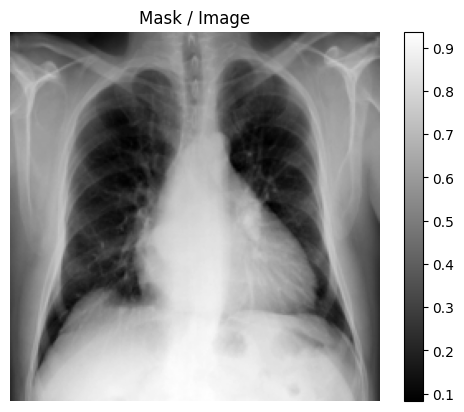

In [13]:
img = sample["image"].squeeze().cpu().numpy()  # remove channel dim

plt.imshow(img, cmap='gray')
plt.colorbar()
plt.title("Mask / Image")
plt.axis('off')
plt.show()

### Cropped with mask

In [14]:
def cropped_with_mask(image, mask, bbox, appy_mask=True):
    if bbox is None:
        return image

    x_min, y_min, x_max, y_max = bbox

    cropped_img = image[y_min:y_max, x_min:x_max]
    cropped_mask = mask[y_min:y_max, x_min:x_max]

    if appy_mask:
        binary_mask = (cropped_mask > 0).astype(np.uint8)

        if len(cropped_img.shape) == 3:
            focused_image = cropped_img * binary_mask[:, :, np.newaxis]
        else:
            focused_image = cropped_img * binary_mask

        return focused_image

    return cropped_img


In [15]:
IDX = 23
image = get_image(IDX)
image_index = segmentation_masks.loc[IDX, "Image Index"]

mask = get_combined_mask_by_image_index(
    image_index=image_index,
    segmentation_masks_df=segmentation_masks,
    height=1024,
    width=1024,
 )
bbox_coords = get_bbox_coordinates(mask)

In [16]:
focused_image = cropped_with_mask(image, mask, bbox_coords, appy_mask=True)
non_focused_image = cropped_with_mask(image, mask, bbox_coords, appy_mask=False)


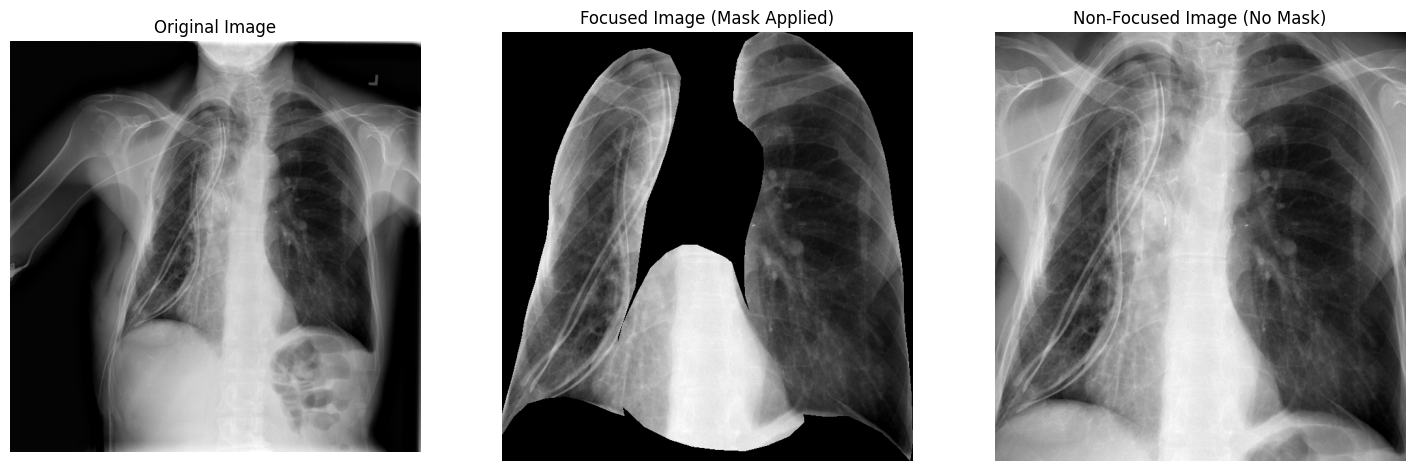

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Oryginalne zdjęcie")
axes[0].axis("off")
axes[1].imshow(non_focused_image, cmap="gray")
axes[1].set_title("Skupione zdjęcie (Przycięcie do maski)")
axes[1].axis("off")
plt.show()

### Custom PyTorch Dataset 

#### Mask as a 4th dimension

In [18]:
class FocusedPathologyDataset(Dataset):
    def __init__(self, df, images_array, labels_array, mask_array, indices: list | None, transform=None):
        self.df = df
        self.images_array = images_array
        self.labels_array = labels_array
        self.mask_array = mask_array
        self.transform = transform

        if indices is None:
            self.indices = list(range(len(df)))
        else:
            self.indices = np.asarray(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        idx = self.indices[idx]

        img_raw = self.images_array[idx]
        mask_raw = self.mask_array[idx]

        img_t = torch.from_numpy(img_raw).float() / 255.0
        mask_t = torch.from_numpy(mask_raw).float() / 255.0

        combined = torch.stack([img_t, mask_t], dim=0)

        if self.transform is not None:
            combined = self.transform(combined)

        target = torch.tensor(self.labels_array[idx], dtype=torch.float32)
        image_index = self.df.iloc[idx]["image_index"]

        return {
            "image": combined,
            "target": target,
            "image_index": image_index,
        }



### Testing the dataset

In [19]:
segmentation_masks.head()

,Image Index,Dice RCA (Mean),Dice RCA (Max),Landmarks,Left Lung,Right Lung,Heart,Height,Width
0,00025787_047.png,0.826465,0.870102,"488,115,449,118,411,132,374,153,344,177,324,20...",200402 3 201422 11 202442 18 203463 24 204483 ...,118243 8 119254 24 120265 40 121281 51 122302 ...,448036 9 449048 27 450064 41 451086 48 452107 ...,1024,1024
1,00026251_000.png,0.833988,0.928886,"426,124,386,128,345,146,303,171,270,203,246,23...",136822 22 137826 46 138848 52 139870 58 140892...,127399 7 128413 21 129427 35 130441 49 131458 ...,445964 26 446985 33 448007 40 449028 47 450049...,1024,1024
2,00026194_002.png,0.759308,0.794598,"439,217,402,226,371,245,345,271,324,297,311,32...",189085 9 190096 27 191113 39 192135 45 193158 ...,221645 20 222646 45 223666 50 224686 56 225706...,395796 5 396816 13 397836 21 398856 29 399877 ...,1024,1024
3,00025227_012.png,0.903819,0.930990,"397,79,357,82,314,98,274,128,236,165,212,205,1...",100976 22 101998 45 103020 49 104042 53 105064...,81288 8 82299 23 83309 40 84325 50 85346 55 86...,498141 13 499161 29 500181 36 501201 43 502221...,1024,1024
4,00028166_003.png,0.850303,0.869093,"392,180,374,184,353,201,327,225,304,250,284,27...",163435 4 164455 12 165475 20 166496 27 167516 ...,184711 4 185731 12 186750 20 187770 27 188791 ...,464455 11 465455 37 466458 59 467469 74 468485...,1024,1024


In [20]:
xray_train_val.head()

,image_index,finding_labels,patient_age,patient_sex,view_position,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia
0,00000001_000.png,Cardiomegaly,57,M,PA,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,58,M,PA,0,0,0,0,0,0,0,0,1,1,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,58,M,PA,0,1,0,0,0,0,0,0,1,0,0,0,0,0
3,00000002_000.png,No Finding,80,M,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000004_000.png,Mass|Nodule,82,M,AP,0,0,0,1,1,0,0,0,0,0,0,0,0,0


In [21]:
small_subset = xray_train_val.iloc[:20]
small_subset.head()

,image_index,finding_labels,patient_age,patient_sex,view_position,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia
0,00000001_000.png,Cardiomegaly,57,M,PA,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,58,M,PA,0,0,0,0,0,0,0,0,1,1,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,58,M,PA,0,1,0,0,0,0,0,0,1,0,0,0,0,0
3,00000002_000.png,No Finding,80,M,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000004_000.png,Mass|Nodule,82,M,AP,0,0,0,1,1,0,0,0,0,0,0,0,0,0


In [22]:
small_subset['mask_array'] = small_subset['image_index'].apply(
    lambda img_idx: get_combined_mask_by_image_index(img_idx, segmentation_masks, 1024, 1024)
)

[05/01/26 12:14:21] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_16544\3882801103.py:1:     ]8;id=774230;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=850113;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             SettingWithCopyWarning:                                                               
                             A value is trying to be set on a copy of a slice from a DataFrame.                    
                             Try using .loc = value instead                                                        
                                                                                                                   
                             See the caveats in the documentation:                                                 
                             https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#                
                             returning-a-view-versus-a-copy                                                        
                               small_subset['mask_array'] = small_subset['image_index'].apply(                     
                                                                                                                   

In [23]:
small_subset

,image_index,finding_labels,patient_age,patient_sex,view_position,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation,Pleural_Thickening,Cardiomegaly,Emphysema,Edema,Fibrosis,Pneumonia,Hernia,mask_array
0,00000001_000.png,Cardiomegaly,57,M,PA,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,00000001_001.png,Cardiomegaly|Emphysema,58,M,PA,0,0,0,0,0,0,0,0,1,1,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,00000001_002.png,Cardiomegaly|Effusion,58,M,PA,0,1,0,0,0,0,0,0,1,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,00000002_000.png,No Finding,80,M,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,00000004_000.png,Mass|Nodule,82,M,AP,0,0,0,1,1,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
5,00000005_000.png,No Finding,69,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
6,00000005_001.png,No Finding,69,F,AP,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
7,00000005_002.png,No Finding,69,F,AP,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
8,00000005_003.png,No Finding,69,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
9,00000005_004.png,No Finding,70,F,PA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [24]:
import cv2

def crop_resize_dual(img_np, image_index, segmentation_masks_df, output_size):

    full_mask = get_combined_mask_by_image_index(image_index, segmentation_masks_df, img_np.shape[0], img_np.shape[1])


    bbox = get_bbox_coordinates(full_mask)

    if bbox:
        x_min, y_min, x_max, y_max = bbox

        img_crop = img_np[y_min:y_max, x_min:x_max]
        mask_crop = full_mask[y_min:y_max, x_min:x_max]
    else:
        img_crop, mask_crop = img_np, full_mask

    img_res = cv2.resize(img_crop, (output_size, output_size), interpolation=cv2.INTER_AREA)
    mask_res = cv2.resize(mask_crop, (output_size, output_size), interpolation=cv2.INTER_NEAREST)

    return img_res, mask_res

def precompute_dual_memmaps(
    df: pd.DataFrame,
    segmentation_masks_df: pd.DataFrame,
    images_dir: str,
    output_img_path: str,
    output_mask_path: str,
    image_col: str = "image_index",
    output_size: int = 512,
    margin_ratio: float = 0.08,
    min_bbox_size: int = 64,
) -> None:
    images_dir = Path(images_dir)
    n = len(df)


    img_arr = np.lib.format.open_memmap(
        output_img_path, dtype=np.uint8, mode="w+", shape=(n, output_size, output_size)
    )
    # Masks: uint8 [N, 512, 512]
    mask_arr = np.lib.format.open_memmap(
        output_mask_path, dtype=np.uint8, mode="w+", shape=(n, output_size, output_size)
    )

    for i, image_name in enumerate(tqdm(df[image_col].tolist(), total=n)):
        img_path = images_dir / image_name

        with Image.open(img_path) as img:
            img_np = np.array(img.convert("L"), dtype=np.uint8)

        img_cropped, mask_cropped = crop_resize_dual(
            img_np=img_np,
            image_index=image_name,
            segmentation_masks_df=segmentation_masks_df,
            output_size=output_size,
            margin_ratio=margin_ratio,
            min_bbox_size=min_bbox_size,
        )

        img_arr[i] = img_cropped
        mask_arr[i] = mask_cropped

    img_arr.flush()
    mask_arr.flush()

### Test `FocusedPathologyDataset` on `small_subset`

100%|██████████| 20/20 [00:01<00:00, 16.20it/s]


Single sample image shape: torch.Size([2, 224, 224])
Single sample target shape: torch.Size([14])
Single sample image_index: 00000001_000.png
Batch image shape: torch.Size([4, 2, 224, 224])
Batch target shape: torch.Size([4, 14])


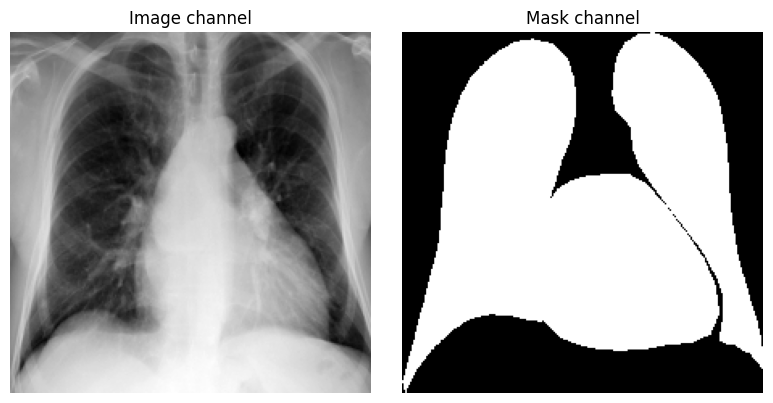

In [25]:
from torch.utils.data import DataLoader

SMALL_N = 20
OUTPUT_SIZE = 224
IMAGES_DIR = Path("data/01_raw/images")

small_subset = xray_train_val.iloc[:SMALL_N].reset_index(drop=True).copy()

small_images = []
small_masks = []

for image_name in tqdm(small_subset["image_index"].tolist(), total=len(small_subset)):
    img_path = IMAGES_DIR / image_name
    with Image.open(img_path) as img:
        img_np = np.array(img.convert("L"), dtype=np.uint8)

    img_resized, mask_resized = crop_resize_dual(
        img_np=img_np,
        image_index=image_name,
        segmentation_masks_df=segmentation_masks,
        output_size=OUTPUT_SIZE,
    )

    small_images.append(img_resized)
    small_masks.append(mask_resized)

small_images = np.stack(small_images).astype(np.uint8)
small_masks = np.stack(small_masks).astype(np.uint8)
small_labels = small_subset[PATHOLOGY_LIST].values.astype(np.float32)

small_dataset = FocusedPathologyDataset(
    df=small_subset,
    images_array=small_images,
    labels_array=small_labels,
    mask_array=small_masks,
    indices=None,
    transform=None,
)

sample = small_dataset[0]
print("Single sample image shape:", sample["image"].shape)
print("Single sample target shape:", sample["target"].shape)
print("Single sample image_index:", sample["image_index"])

loader = DataLoader(small_dataset, batch_size=4, shuffle=False)
batch = next(iter(loader))
print("Batch image shape:", batch["image"].shape)
print("Batch target shape:", batch["target"].shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample["image"][0].cpu().numpy(), cmap="gray")
axes[0].set_title("Image channel")
axes[0].axis("off")

axes[1].imshow(sample["image"][1].cpu().numpy(), cmap="gray")
axes[1].set_title("Mask channel")
axes[1].axis("off")

plt.tight_layout()
plt.show()